We want to be ablle to see if it's viable to sell Pixel Phones on Colombia using data that we can found. We will try to use Data Cleaning and Collection techniques from the industry, the proper analysis and visualiation of the data on this Jupyter Notebook.

We have this keypoints to try to answer:

* Si queremos estar lado a lado con las opcioens que se encuentran en Colombia, ¿Que precio deberan tener los telefonos? teniendo minimo un margen del 15% sobre el precio de importacion y compra. (Estamos tomando el valor de minimo 15% como si tuvieramos un sponsor que solo espera ver de regreso un 10% extra de su inversion, y nosotros queremos solo un side earning)
* En base a la venta de los telefonos por precio en Colombia, ¿Cuales serian las ganancias que podriamos esperar por mes?
* ¿Que medio virtual vende más en Cololmbia en el mercado de telefonia?

Listamos aca las fuentes de los datos, y si sacamos con web scraping, mostraremos link a los .csv.

DataSet of Sold Phones by Brand in the last 12 months (until February 2026)
https://gs.statcounter.com/vendor-market-share/mobile/colombia; donde extrajimos "mobile_sales_colombia_by_brand_mar_2025_to_feb_2025.csv" y el reporte anual del 2025 y 2024

Most sold phones by the top 4 brands in Colombia in the last 24 months.

USE PYTRENDS TO GET ALL THE TRENDS OF SEARCHS ON COLOMBIA FROM MODELS OF PHONES FROM THE TOP 4, USE THAT DATA TO GET WITH SCRAPING PRICE AND ALSO USING WEB ARCHIVE.
Using AI we got every phone launched from Apple, Samsung, Xiaomi and Motorola since 2023. -> 'smartphones_2023_2026.csv'

Popularidad en Google Trends en los ultimos 5 años.
https://trends.google.com/explore?q=xiaomi%2Csamsung%2Ciphone%2Cmotorola&date=today%205-y&geo=CO -> 'google_trends_CO_20210307-20260307.csv'


In [1]:
import pandas as pd
import numpy as np

In [2]:
#We Want to merge all our data of sold phones by brand into a single data frame and check if it's clean
dataset_mobile_share_data_2025 = './Databases/vendor-CO-monthly-202501-202512.csv'
dataset_mobile_share_data_2024 = './Databases/vendor-CO-monthly-202401-202412.csv'
dataset_mobile_share_data_last_12_moths = './Databases/mobile_sales_colombia_by_brand_mar_2025_to_feb_2025.csv'
dataset_phones_launched_by_top_4_brands_since_2023 = './Databases/smartphones_2023_2026.csv'

mobile_share_data_2025 = pd.read_csv(dataset_mobile_share_data_2025, delimiter = ',')
mobile_share_data_2024 = pd.read_csv(dataset_mobile_share_data_2024, delimiter = ',')
mobile_share_data_last_12_months = pd.read_csv(dataset_mobile_share_data_last_12_moths, delimiter = ',')
phones_launched_top_4__brand_since_2023  = pd.read_csv(dataset_phones_launched_by_top_4_brands_since_2023, delimiter=',')
mobile_share_data_2025

,Date,Samsung,Apple,Xiaomi,Motorola,Unknown,Oppo,Huawei,Tecno,Vivo,...,Nokia,Mixc,LG,Lenovo,OnePlus,TCL,Asus,Sony,Alcatel,Other
0,2025-01,23.76,27.22,19.11,11.53,2.47,2.71,3.15,2.03,2.13,...,0.45,0.23,0.24,0.17,0.08,0.08,0.03,0.02,0.02,0.05
1,2025-02,21.82,32.98,17.79,10.82,2.27,2.38,2.94,1.69,1.96,...,0.36,0.21,0.23,0.13,0.08,0.06,0.03,0.02,0.02,0.04
2,2025-03,23.19,27.90,18.75,11.32,3.04,2.94,3.00,1.72,2.27,...,0.40,0.21,0.22,0.14,0.08,0.07,0.03,0.03,0.02,0.05
3,2025-04,23.41,27.08,17.70,11.54,3.74,3.38,2.81,1.68,2.15,...,0.38,0.19,0.22,0.16,0.09,0.07,0.03,0.01,0.02,0.04
4,2025-05,25.44,14.19,26.30,9.53,6.83,3.39,2.28,3.45,2.74,...,0.26,0.22,0.19,0.07,0.06,0.04,0.01,0.01,0.01,0.02
5,2025-06,26.56,8.69,28.00,10.09,7.77,3.97,2.25,4.44,2.55,...,0.25,0.22,0.14,0.06,0.07,0.06,0.01,0.00,0.00,0.04
6,2025-07,22.79,28.32,17.31,11.62,4.06,3.36,2.53,1.56,2.15,...,0.36,0.18,0.16,0.14,0.09,0.06,0.03,0.01,0.01,0.03
7,2025-08,23.03,28.87,16.66,11.60,4.26,3.29,2.49,1.47,2.13,...,0.43,0.15,0.16,0.15,0.08,0.06,0.03,0.01,0.01,0.03
8,2025-09,22.72,30.41,15.67,11.01,4.14,3.14,2.25,1.41,2.05,...,0.39,0.24,0.15,0.12,0.08,0.06,0.03,0.01,0.01,0.03
9,2025-10,22.23,32.53,15.22,10.97,4.20,3.16,2.03,1.39,2.00,...,0.30,0.18,0.14,0.12,0.08,0.07,0.02,0.01,0.01,0.02


In [3]:
mobile_share_data_last_12_months

,Date,Apple,Samsung,Xiaomi,Motorola,Unknown,Oppo,Tecno,Huawei,Vivo,...,Realme,ZTE,Nokia,Mixc,LG,Lenovo,OnePlus,TCL,Asus,Other
0,2025-02,32.98,21.82,17.79,10.82,2.27,2.38,1.69,2.94,1.96,...,0.86,0.43,0.36,0.21,0.23,0.13,0.08,0.06,0.03,0.08
1,2025-03,27.90,23.19,18.75,11.32,3.04,2.94,1.72,3.00,2.27,...,0.90,0.46,0.40,0.21,0.22,0.14,0.08,0.07,0.03,0.10
2,2025-04,27.08,23.41,17.70,11.54,3.74,3.38,1.68,2.81,2.15,...,0.82,0.42,0.38,0.19,0.22,0.16,0.09,0.07,0.03,0.07
3,2025-05,14.19,25.44,26.30,9.53,6.83,3.39,3.45,2.28,2.74,...,0.65,0.43,0.26,0.22,0.19,0.07,0.06,0.04,0.01,0.03
4,2025-06,8.69,26.56,28.00,10.09,7.77,3.97,4.44,2.25,2.55,...,0.72,0.46,0.25,0.22,0.14,0.06,0.07,0.06,0.01,0.04
5,2025-07,28.32,22.79,17.31,11.62,4.06,3.36,1.56,2.53,2.15,...,0.80,0.39,0.36,0.18,0.16,0.14,0.09,0.06,0.03,0.05
6,2025-08,28.87,23.03,16.66,11.60,4.26,3.29,1.47,2.49,2.13,...,0.81,0.39,0.43,0.15,0.16,0.15,0.08,0.06,0.03,0.05
7,2025-09,30.41,22.72,15.67,11.01,4.14,3.14,1.41,2.25,2.05,...,0.75,0.36,0.39,0.24,0.15,0.12,0.08,0.06,0.03,0.05
8,2025-10,32.53,22.23,15.22,10.97,4.20,3.16,1.39,2.03,2.00,...,0.69,0.32,0.30,0.18,0.14,0.12,0.08,0.07,0.02,0.04
9,2025-11,35.01,21.67,14.85,11.08,4.26,3.11,1.37,1.96,2.03,...,0.69,0.31,0.26,0.16,0.12,0.11,0.11,0.06,0.02,0.04


In [4]:
mobile_share_data_2024

,Date,Apple,Samsung,Xiaomi,Motorola,Huawei,Unknown,Oppo,Vivo,Tecno,...,Mixc,Google,Lenovo,TCL,OnePlus,Sony,Asus,Alcatel,T-Mobile,Other
0,2024-01,19.67,25.37,21.80,12.88,5.58,3.01,2.07,2.39,1.56,...,0.42,0.18,0.34,0.10,0.09,0.10,0.08,0.04,0.01,0.06
1,2024-02,21.71,25.09,21.43,12.40,5.21,2.83,2.05,2.37,1.51,...,0.38,0.21,0.28,0.11,0.10,0.10,0.07,0.05,0.01,0.06
2,2024-03,21.59,24.43,20.65,12.50,5.16,4.41,2.05,2.30,1.49,...,0.35,0.24,0.26,0.10,0.08,0.09,0.07,0.04,0.01,0.06
3,2024-04,22.30,24.63,20.58,12.22,4.91,4.24,2.01,2.23,1.51,...,0.34,0.23,0.26,0.13,0.08,0.06,0.07,0.04,0.01,0.05
4,2024-05,22.56,24.33,20.81,12.28,4.59,4.16,2.09,2.22,1.59,...,0.33,0.32,0.26,0.12,0.08,0.07,0.06,0.03,0.01,0.05
5,2024-06,23.14,24.49,21.25,12.25,4.40,2.86,2.21,2.26,1.63,...,0.31,0.37,0.24,0.10,0.10,0.09,0.06,0.03,0.02,0.05
6,2024-07,22.31,24.66,21.45,12.68,4.41,2.18,2.43,2.31,1.78,...,0.32,0.43,0.25,0.11,0.10,0.07,0.06,0.03,0.01,0.05
7,2024-08,24.06,24.06,20.85,12.32,4.18,2.31,2.42,2.23,1.93,...,0.31,0.36,0.23,0.13,0.10,0.06,0.05,0.05,0.01,0.04
8,2024-09,25.05,23.87,20.27,11.98,3.89,2.18,2.62,2.20,2.05,...,0.29,0.31,0.23,0.13,0.08,0.08,0.04,0.04,0.00,0.04
9,2024-10,30.97,22.20,18.66,10.96,3.41,1.96,2.38,1.97,1.98,...,0.26,0.29,0.22,0.09,0.08,0.06,0.04,0.05,0.01,0.04


In [4]:
phones_launched_top_4__brand_since_2023

,name,brand,date_launched
0,Galaxy S23,Samsung,2023-02-17
1,Galaxy S23+,Samsung,2023-02-17
2,Galaxy S23 Ultra,Samsung,2023-02-17
3,Galaxy Z Fold5,Samsung,2023-08-11
4,Galaxy Z Flip5,Samsung,2023-08-11
...,...,...,...
85,Motorola Edge (2025),Motorola,2025-05-15
86,Moto G75 5G,Motorola,2025-01-09
87,Moto G56 5G,Motorola,2025-02-20
88,Moto G86 5G,Motorola,2025-03-15


We check that both objects are DataFrames

In [6]:
type(mobile_share_data_2024)

pandas.core.frame.DataFrame

In [7]:
type(mobile_share_data_2025)

pandas.core.frame.DataFrame

In [8]:
type(mobile_share_data_last_12_months)

pandas.core.frame.DataFrame

In [9]:
type(phones_launched_top_4__brand_since_2023)

pandas.core.frame.DataFrame

Now we obtain the full data frame with the 26 month data with market by brand in Colombia

In [5]:
df = pd.concat([mobile_share_data_2024, mobile_share_data_2025, mobile_share_data_last_12_months], ignore_index=True)
df = df.drop_duplicates(subset=['Date'])
df

,Date,Apple,Samsung,Xiaomi,Motorola,Huawei,Unknown,Oppo,Vivo,Tecno,...,Mixc,Google,Lenovo,TCL,OnePlus,Sony,Asus,Alcatel,T-Mobile,Other
0,2024-01,19.67,25.37,21.80,12.88,5.58,3.01,2.07,2.39,1.56,...,0.42,0.18,0.34,0.10,0.09,0.10,0.08,0.04,0.01,0.06
1,2024-02,21.71,25.09,21.43,12.40,5.21,2.83,2.05,2.37,1.51,...,0.38,0.21,0.28,0.11,0.10,0.10,0.07,0.05,0.01,0.06
2,2024-03,21.59,24.43,20.65,12.50,5.16,4.41,2.05,2.30,1.49,...,0.35,0.24,0.26,0.10,0.08,0.09,0.07,0.04,0.01,0.06
3,2024-04,22.30,24.63,20.58,12.22,4.91,4.24,2.01,2.23,1.51,...,0.34,0.23,0.26,0.13,0.08,0.06,0.07,0.04,0.01,0.05
4,2024-05,22.56,24.33,20.81,12.28,4.59,4.16,2.09,2.22,1.59,...,0.33,0.32,0.26,0.12,0.08,0.07,0.06,0.03,0.01,0.05
5,2024-06,23.14,24.49,21.25,12.25,4.40,2.86,2.21,2.26,1.63,...,0.31,0.37,0.24,0.10,0.10,0.09,0.06,0.03,0.02,0.05
6,2024-07,22.31,24.66,21.45,12.68,4.41,2.18,2.43,2.31,1.78,...,0.32,0.43,0.25,0.11,0.10,0.07,0.06,0.03,0.01,0.05
7,2024-08,24.06,24.06,20.85,12.32,4.18,2.31,2.42,2.23,1.93,...,0.31,0.36,0.23,0.13,0.10,0.06,0.05,0.05,0.01,0.04
8,2024-09,25.05,23.87,20.27,11.98,3.89,2.18,2.62,2.20,2.05,...,0.29,0.31,0.23,0.13,0.08,0.08,0.04,0.04,0.00,0.04
9,2024-10,30.97,22.20,18.66,10.96,3.41,1.96,2.38,1.97,1.98,...,0.26,0.29,0.22,0.09,0.08,0.06,0.04,0.05,0.01,0.04


In [13]:
import plotly.graph_objects as go
import plotly.express as px

brand_colors = {
    'Apple':    '#636363',
    'Samsung':  '#1428A0',
    'Xiaomi':   '#FF6900',
    'Motorola': '#E1001A',
    'Huawei':   '#CF0A2C',
    'Unknown':  '#999999',
    'Oppo':     '#1DB954',
}

fig = go.Figure()

# Una línea por cada marca
for brand, color in brand_colors.items():
    if brand in df.columns:
        fig.add_trace(go.Scatter(
            x=df['Date'],
            y=df[brand],
            mode='lines+markers',
            name=brand,
            line=dict(color=color, width=2),
            marker=dict(size=5),
            hovertemplate=f'<b>{brand}</b><br>%{{x}}<br>%{{y:.2f}}%<extra></extra>'
        ))

fig.update_layout(
    title=dict(
        text='Mobile Vendor Market Share Colombia<br>'
             '<sup>2024 - 2026</sup>',
        font=dict(size=20, color='#1a1a2e'),
        x=0.05
    ),
    paper_bgcolor='white',
    plot_bgcolor='#f9f9f9',
    xaxis=dict(
        title='',
        gridcolor='#ebebeb',
        showline=True,
        linecolor='#cccccc',
    ),
    yaxis=dict(
        title='Market Share (%)',
        ticksuffix='%',
        gridcolor='#ebebeb',
        showline=True,
        linecolor='#cccccc',
    ),
    legend=dict(
        orientation='h',
        y=-0.15,
        x=0.5,
        xanchor='center',
        bgcolor='white',
        bordercolor='#ebebeb',
        borderwidth=1
    ),
    hovermode='x unified',
    height=500
)

fig.show(renderer='iframe')

<Axes: >

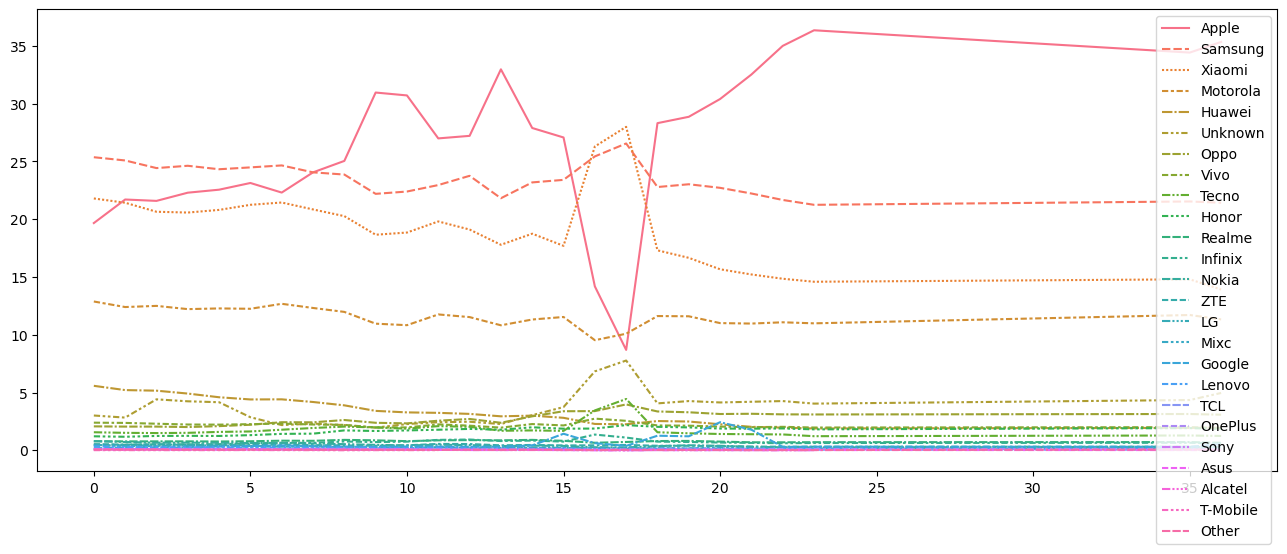

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16,6))
sns.lineplot(data=df)

Queremos hacer un estimado de los telefonos mas vendidos en Colmbia usando google trends entre los top 4, para luego conseguir el precio de los top 5 mas populares por marca en lanzamiento.
Usaremos pytrends para hacer la investigacion, una libreria no oficial para conseguir google trends data using python.

In [15]:
!pip install pytrends

In [7]:
from pytrends.request import TrendReq

pytrends = TrendReq(hl='en-CO', tz=360)

In [8]:
kw_list = phones_launched_top_4__brand_since_2023['name'].tolist()

pd.set_option('future.no_silent_downcasting', True)

# Pytrends solo acepta max 5 keywords a la vez
chunks = [kw_list[i:i+5] for i in range(0, len(kw_list), 5)]

results = []
for chunk in chunks:
    pytrends.build_payload(chunk, cat=0, timeframe='today 5-y', geo='', gprop='')
    df_trend = pytrends.interest_over_time()
    results.append(df_trend)

df_trends = pd.concat(results, axis=1)

TooManyRequestsError: The request failed: Google returned a response with code 429

In [18]:
print(type(phones_launched_top_4__brand_since_2023))
print(phones_launched_top_4__brand_since_2023)

<class 'pandas.core.frame.DataFrame'>
                    name     brand date_launched
0             Galaxy S23   Samsung    2023-02-17
1            Galaxy S23+   Samsung    2023-02-17
2       Galaxy S23 Ultra   Samsung    2023-02-17
3         Galaxy Z Fold5   Samsung    2023-08-11
4         Galaxy Z Flip5   Samsung    2023-08-11
..                   ...       ...           ...
85  Motorola Edge (2025)  Motorola    2025-05-15
86           Moto G75 5G  Motorola    2025-01-09
87           Moto G56 5G  Motorola    2025-02-20
88           Moto G86 5G  Motorola    2025-03-15
89              Moto G96  Motorola    2025-04-10

[90 rows x 3 columns]


In [19]:
df_trends

,Galaxy S23,Galaxy S23+,Galaxy S23 Ultra,Galaxy Z Fold5,Galaxy Z Flip5,isPartial,Galaxy S23 FE,Galaxy A14,Galaxy A14 5G,Galaxy A54 5G,...,Motorola Razr (2025),Motorola Razr+ (2025),Motorola Razr Ultra (2025),isPartial,Motorola Edge (2025),Moto G75 5G,Moto G56 5G,Moto G86 5G,Moto G96,isPartial
date,,,,,,,,,,,,,,,,,,,,,
2021-03-07,0,0,0,0,0,False,0,0,0,0,...,0,0,0,False,0,0,0,0,0,False
2021-03-14,0,0,0,0,0,False,0,0,0,0,...,0,0,0,False,0,0,0,0,0,False
2021-03-21,0,0,0,0,0,False,0,0,0,0,...,0,0,0,False,0,0,0,0,0,False
2021-03-28,0,0,0,0,0,False,0,0,0,0,...,0,0,0,False,0,0,0,0,0,False
2021-04-04,0,0,0,0,0,False,0,0,0,0,...,0,0,0,False,0,0,0,0,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-08,51,50,16,10,10,False,9,10,1,1,...,0,28,0,False,19,4,7,11,17,False
2026-02-15,63,67,19,13,12,False,12,13,1,1,...,0,28,0,False,20,4,7,12,17,False
2026-02-22,37,35,11,6,6,False,6,7,1,1,...,0,19,0,False,9,3,7,11,16,False


In [6]:
df_sum = df_trends.sum().reset_index()
df_sum.columns = ['name', 'total_searches']

df_merged = df_sum.merge(phones_launched_top_4__brand_since_2023[['name','brand']], on = 'name', how = 'left')

top5_samsung  = (df_merged[df_merged['brand'] == 'Samsung']
                 .sort_values('total_searches', ascending=False)
                 .head(5)
                 .reset_index(drop=True))

top5_apple = (df_merged[df_merged['brand'] == 'Apple']
              .sort_values('total_searches', ascending=False)
              .head(5)
              .reset_index(drop=True))

top5_xiaomi   = (df_merged[df_merged['brand'] == 'Xiaomi']
                 .sort_values('total_searches', ascending=False)
                 .head(5)
                 .reset_index(drop=True))

top5_motorola = (df_merged[df_merged['brand'] == 'Motorola']
                 .sort_values('total_searches', ascending=False)
                 .head(5)
                 .reset_index(drop=True))


NameError: name 'df_trends' is not defined

In [21]:
df_merged = pd.concat([top5_samsung, top5_apple, top5_xiaomi, top5_motorola], ignore_index=False)
df_merged

,name,total_searches,brand
0,Galaxy S23+,4966,Samsung
1,Galaxy S23,4958,Samsung
2,Galaxy S24+,3673,Samsung
3,Galaxy S24,3673,Samsung
4,Galaxy S25,2954,Samsung
0,iPhone 15,2643,Apple
1,iPhone 16,2269,Apple
2,iPhone 15 Pro,1393,Apple
3,iPhone 17 Pro,1113,Apple
4,iPhone 17,1025,Apple


In [22]:
df_merged = df_merged.sort_values('total_searches', ascending = False)
df_merged

,name,total_searches,brand
0,Redmi Note 12,6703,Xiaomi
1,Redmi Note 12 Pro,6630,Xiaomi
2,Redmi Note 12 Pro+,6623,Xiaomi
3,Redmi Note 13,6333,Xiaomi
0,Moto G24,6299,Motorola
4,Xiaomi 14,5857,Xiaomi
1,Motorola Edge+ (2023),5475,Motorola
2,Motorola Razr+ (2023),5393,Motorola
3,Motorola Razr+ (2024),4973,Motorola
0,Galaxy S23+,4966,Samsung


In [23]:
dic_prices = {
    'Redmi Note 12 Pro' : 949000,
    'Redmi Note 12 Pro+' : 1199000,
    'Redmi Note 12' : 549000,
    'Redmi Note 13' : 999900,
    'Moto G24' : 660005,
    'Xiaomi 14' : 830000,
    'Motorola Edge+ (2023)' : 1200000,
    'Motorola Razr+ (2023)' : 1165000,
    'Motorola Razr+ (2024)' : 1600000,
    'Galaxy S23+' : 3799000,
    'Galaxy S23' : 2999000,
    'Motorola Razr+ (2025)' : 3600000,
    'Galaxy S24' : 2999000,
    'Galaxy S24+' : 3599000,
    'Galaxy S25' : 2799000,
    'iPhone 15' : 2650000,
    'iPhone 16' : 2880000,
    'iPhone 15 Pro' : 4199000,
    'iPhone 17 Pro' : 5365000,
    'iPhone 17' : 3400000
}

df_merged['price_cop'] = df_merged['name'].map(dic_prices)
df_merged   
    

,name,total_searches,brand,price_cop
0,Redmi Note 12,6703,Xiaomi,549000
1,Redmi Note 12 Pro,6630,Xiaomi,949000
2,Redmi Note 12 Pro+,6623,Xiaomi,1199000
3,Redmi Note 13,6333,Xiaomi,999900
0,Moto G24,6299,Motorola,660005
4,Xiaomi 14,5857,Xiaomi,830000
1,Motorola Edge+ (2023),5475,Motorola,1200000
2,Motorola Razr+ (2023),5393,Motorola,1165000
3,Motorola Razr+ (2024),4973,Motorola,1600000
0,Galaxy S23+,4966,Samsung,3799000


/tmp/ipykernel_182151/409850614.py:72: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/pachita-ubuntu/.config/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


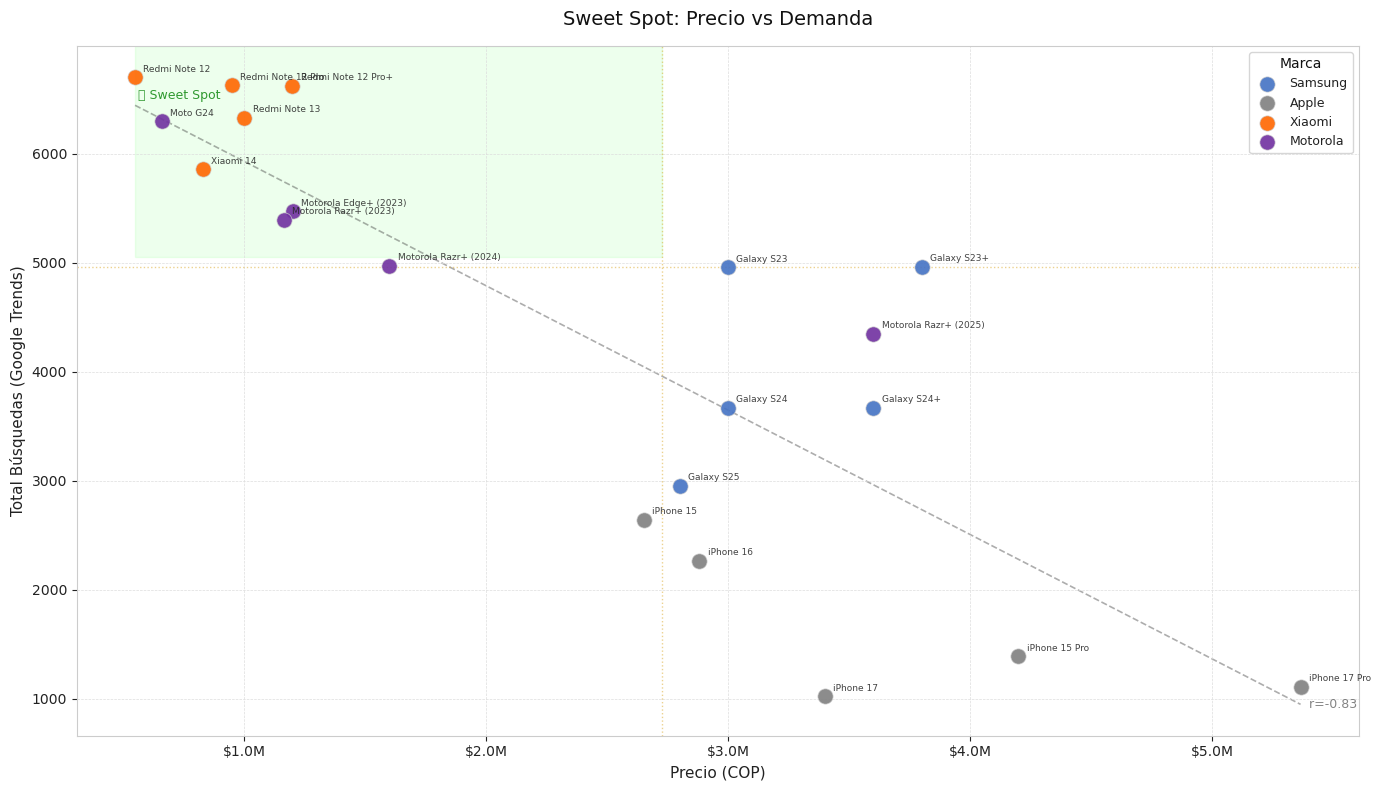

<Figure size 640x480 with 0 Axes>

In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from scipy import stats

# Setup
brand_colors = {
    'Samsung': '#4472C4',   # Azul StatCounter
    'Apple':   '#808080',   # Gris StatCounter
    'Xiaomi':  '#FF6600',   # Naranja StatCounter
    'Motorola':'#7030A0'    # Morado StatCounter
}

df_plot = df_merged.dropna(subset=['price_cop', 'total_searches']).copy()
df_plot['color'] = df_plot['brand'].map(brand_colors)

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('#FFFFFF')
ax.set_facecolor('#FFFFFF')

# --- Línea de regresión general ---
x = df_plot['price_cop']
y = df_plot['total_searches']
slope, intercept, r, p, _ = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 200)
ax.plot(x_line, slope * x_line + intercept,
        color='#333333', linewidth=1.2, linestyle='--', alpha=0.4, zorder=1)
ax.text(x_line[-1], slope * x_line[-1] + intercept,
        f'  r={r:.2f}', color='#333333', fontsize=9, alpha=0.6, va='center')

# --- Zona "sweet spot" (precio medio, búsquedas altas) ---
price_median  = df_plot['price_cop'].median()
search_median = df_plot['total_searches'].median()
ax.axvline(price_median,  color='goldenrod', linestyle=':', alpha=0.5, linewidth=1)
ax.axhline(search_median, color='goldenrod', linestyle=':', alpha=0.5, linewidth=1)

# Sombrear cuadrante sweet spot (precio bajo + búsquedas altas)
ax.axvspan(x.min(), price_median,
           ymin=(search_median - y.min()) / (y.max() - y.min()),
           alpha=0.07, color='lime', zorder=0)
ax.text(x.min() * 1.02, y.max() * 0.97, '🎯 Sweet Spot',
        color='green', fontsize=9, alpha=0.8)

# --- Scatter por marca ---
for brand, color in brand_colors.items():
    subset = df_plot[df_plot['brand'] == brand]
    ax.scatter(subset['price_cop'], subset['total_searches'],
               color=color, s=120, zorder=3, alpha=0.9,
               edgecolors='#CCCCCC', linewidths=0.5, label=brand)

# --- Etiquetas de cada punto ---
for _, row in df_plot.iterrows():
    ax.annotate(row['name'],
                xy=(row['price_cop'], row['total_searches']),
                xytext=(6, 4), textcoords='offset points',
                fontsize=6.5, color='#222222', alpha=0.85)

# --- Formato ejes ---
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1_000_000:.1f}M' if x >= 1_000_000 else f'${x:,.0f}'))
ax.set_xlabel('Precio (COP)', color='#222222', fontsize=11)
ax.set_ylabel('Total Búsquedas (Google Trends)', color='#222222', fontsize=11)
ax.set_title('Sweet Spot: Precio vs Demanda', color='#111111', fontsize=14, pad=15)
ax.tick_params(colors='#222222')
for spine in ax.spines.values():
    spine.set_edgecolor('#CCCCCC')

# Leyenda
legend = ax.legend(title='Marca', facecolor='#FFFFFF',
                   edgecolor='#CCCCCC', labelcolor='#222222', fontsize=9)
legend.get_title().set_color('#111111')

plt.tight_layout()
plt.grid(color='#DDDDDD', linestyle='--', linewidth=0.5)
plt.show()
plt.savefig('grafica.svg', format='svg')

Los puntos presentados a evaluar fueron los siguientes: 

**Si queremos estar lado a lado con las opciones que se encuentran en Colombia, ¿Que precio deberan tener los telefonos? teniendo minimo un margen del 15% sobre el precio de importacion y compra. (Estamos tomando el valor de minimo 15% como si tuvieramos un sponsor que solo espera ver de regreso un 10% extra de su inversion, y nosotros queremos solo un side earning)**
  - Para atacar el precio con buenos margenes de ganancia lo mas recomendable seria vender telefonos con modelos como el Pixel 8 para poder entrar en el rango de precios que con la poca popularidad que tienen en Colombia, compite el precio no el modelo como tal. Ahora, la popularidad del Google Pixel a lo largo de los años tiene picos en su lanzamiento y luego se estabilizan hasta quedar en el mismo promedio para como pasa con el Pixel 8 y el 7. Ahora desde esos dos, el 9 y el 10 han ido teniendo picos cada vez mas altos y mateniendose cada vez mas arriba a lo largo del año, cosa que indica que el interes ira aumentando con el pasar de los años, viendo como los Pixel fueron introducidos hace poco al mercado Mexicano, podriamos como se comparan las ventanas alla en comparacion de como estan las ventas aca en Colombia, si es suficiente la correlacion podriamos ver su desempeño si se crea un distribuidor oficial aca en Colombia. Incluso usando el mismo analisis de popularidad, el Pixel es mas popular en Colombia que en Mexico, asi que tal vez podriaos esperar mejor numeros aca.
  - Aun asi, el pixel 8 debera entrar en no mas de los 1.300.000 COP, para poder esperar un margen real. El indice de popularidad con el Motorola es mas o menos similar, pero su posicion en el mercado es poco pero tienen mucho tiempo en el cosa que les da exposicion sin nunca esperar comparar sus ventas con el siguiente competidor en el top, Xiaomi. Con la popularidad del Pixel 10, sobre los demas, podriamos quizas esperar cierta posicion entre la poblacion que busca saltar de un Samsung o iPhone a un Pixel al no llegar al mismo precio de +3.0M pero si un valor comparable por poco menos de eso cosa que le da un cierto porcentaje de exito mayor.
  - Hay que agregar un breve comentario sobre el rendimiento de ventas de Xiaomi entre Abril y Julio del 2025, donde se evidencia Xiaomi como el mayor en ventas en Colombia sobre Samsung y Apple. Mi teoria es que va a la par con el lanzamiento de la serie Note 14/15, serie bastante popular entre los que buscan adaptar un nuevo telefono dentro del goldilocks zone de gama media.
 
**En base a la venta de los telefonos por precio en Colombia, ¿Cuales serian las ganancias que podriamos esperar por mes?**
- Es posible esperar no mas de 5 ventas al mes, incluso podriamos ver su rendimiento usado en mercados tercerizados como Marketplace u usados en Mercado Libre donde cuesta que salgan de ese espacio y sus ventans no pasan los 10 por mes. Haciendo la compra de dos Pixel 10 y 10 Pixel 8 y 5 Pixel 9a podria ser un buen punto de inicio para probar con datos reales de venta en base a como atacamos al mercado al precio que podemos alcanzar, el mas recomenado a un precio no lejano de la zona con mejor interes, y el Pixel 10 por interes general sobre la linea en Colombia.

**¿Que medio virtual vende más en Cololmbia en el mercado de telefonia?**
- Los iphone tienen la mayor popularidad en telefonia en MercadoLibre un lugar facilmente visto por su diferencia de precios con MacCenter o iShop, vendedores oficiales de los productos Apple. Aun asi, Apple tiene validacion de la venta de algunos de estos productos en ciertas tiendas, cosa que al cliente le podria dar un poco mas de seguridad y confianza. Poder conseguir el sello de verificacion de Google podria ayudar a conseguir algo de confianza por parte del cliente. Marketplace tambien muestra cierto interes, más lo central en la localidad podria afectar. 